In [1]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

drive.mount('/content/drive')
# Change this path to where your folder is located
data_dir = '/content/drive/MyDrive/LIDAR_based_AVC/Data'

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Automatically sets aside 20% for testing
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2575 images belonging to 3 classes.
Found 642 images belonging to 3 classes.


In [4]:
# Formulas: total / (num_classes * num_images_in_class)
class_weights = {
    0: 1.33, # Bus (1350 / (3 * 250))
    1: 0.45, # Car (1350 / (3 * 1000))
    2: 4.5   # Truck (1350 / (3 * 100))
}
# Note: Check train_generator.class_indices to ensure 0, 1, 2 match Bus, Car, Truck

In [5]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze the pre-trained weights

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # 3 classes: Car, Bus, Truck
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
47/81 ━━━━━━━━━━━━━━━━━━━━ 1:34 3s/step - accuracy: 0.8313 - loss: 0.6455

In [ ]:
# Save as a single .keras file (recommended format)
model.save('/content/drive/MyDrive/my_vehicle_model.keras')

# Or download it directly to your computer
from google.colab import files
model.save('my_vehicle_model.keras')
files.download('my_vehicle_model.keras')

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
    # Load and prepare the image
    img = image.load_img(fn, target_size=(224, 224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Predict
    classes = model.predict(x)

    # Map the prediction back to labels
    # Note: Check your train_generator.class_indices to confirm order
    labels = list(train_generator.class_indices.keys())
    print(f"Prediction for {fn}: {labels[np.argmax(classes)]}")

In [ ]:
import tensorflow as tf

# Load your model (if not already in memory)
model = tf.keras.models.load_model('/content/drive/MyDrive/my_vehicle_model.keras')

# Convert to TFLite with quantization (makes it 4x smaller and faster)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite version
with open('vehicle_model_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
    # Load and prepare the image
    img = image.load_img(fn, target_size=(224, 224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Predict
    classes = model.predict(x)

    # Map the prediction back to labels
    # Note: Check your train_generator.class_indices to confirm order
    labels = list(train_generator.class_indices.keys())
    print(f"Prediction for {fn}: {labels[np.argmax(classes)]}")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup the Test Generator (Only rescaling, NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data/Test', # Path to your test folder
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep false to align predictions with true labels
)

# 2. Run Evaluation
results = model.evaluate(test_generator)

print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

In [ ]:
# Double-check this path in your Google Drive sidebar
test_path = '/content/drive/MyDrive/Data/Test'

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# This will now show "Found X images belonging to 3 classes"
results = model.evaluate(test_generator)
print(f"Test Accuracy: {results[1]*100:.2f}%")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

# Load the saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/my_vehicle_model.keras')

print("Model loaded successfully! You can now resume testing or evaluation.")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data1/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data1/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# We set class_mode=None because there are no real labels to compare to
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Data1/Test', # The parent folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict all images at once
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Show results
labels = list(train_generator.class_indices.keys())
for i, filename in enumerate(test_generator.filenames):
    print(f"Image: {filename} -> Predicted: {labels[predicted_classes[i]]}")

In [ ]:
import tensorflow as tf
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your saved model (verify this path in your Drive)
model_path = '/content/drive/MyDrive/my_vehicle_model.keras'

# 3. Load the Model
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("✅ Model loaded successfully from Drive!")
else:
    print("❌ Error: 'my_vehicle_model.keras' not found. Please check your Drive folder.")

Mounted at /content/drive
✅ Model loaded successfully from Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Path to your test data containing the 3 subfolders (car, bus, truck)
test_path = '/content/drive/MyDrive/Colab Notebooks/Test'

# 2. Setup the Test Generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 3. Calculate Accuracy
if test_generator.samples > 0:
    print("\nStarting evaluation...")
    results = model.evaluate(test_generator)
    print(f"\n--- Final Results ---")
    print(f"Test Accuracy: {results[1]*100:.2f}%")
    print(f"Test Loss: {results[0]:.4f}")
else:
    print("❌ Error: No images found. Ensure your folders are named correctly inside 'test_data'.")

Found 186 images belonging to 3 classes.

Starting evaluation...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.9846 - loss: 0.0634

--- Final Results ---
Test Accuracy: 94.62%
Test Loss: 0.2087


6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Total misclassified images: 10 out of 186



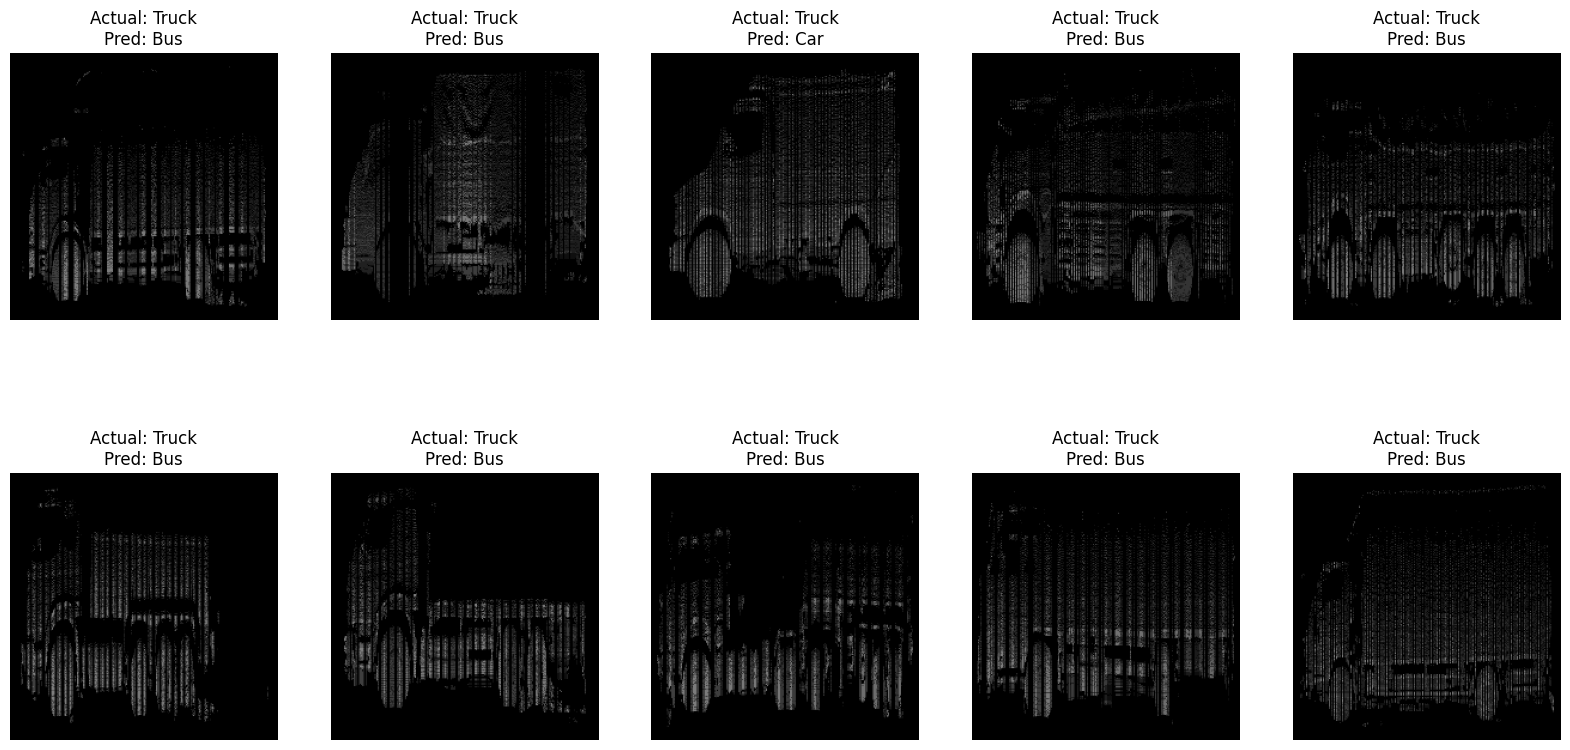

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions for the entire test set
test_generator.reset() # Ensure we start from the beginning
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# 2. Get true labels and filenames
true_classes = test_generator.classes
filenames = test_generator.filenames
class_labels = list(test_generator.class_indices.keys())

# 3. Find the indices where predictions do not match truth
errors = np.where(predicted_classes != true_classes)[0]
print(f"Total misclassified images: {len(errors)} out of {len(filenames)}\n")

# 4. Show the first 5 errors with their images
# Change this line in Cell 3:
num_to_show = len(errors)

# The rest of the loop stays the same
plt.figure(figsize=(20, 10)) # Made figure wider to fit more images
for i, error_idx in enumerate(errors):
    img_path = os.path.join(test_path, filenames[error_idx])
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))

    plt.subplot(2, 5, i + 1) # 2 rows of 5 images each
    plt.imshow(img)
    plt.title(f"Actual: {class_labels[true_classes[error_idx]]}\nPred: {class_labels[predicted_classes[error_idx]]}")
    plt.axis('off')